# Mean-Reversion Strategy — Results

DJ30 universe · Daily data 2014–2026 · CAPM residual z-score signal · Top-3 long-only · Weekly rebalance

**Splits:** Train 2014–2019 | Val 2020–2022 | Test 2023–2025

In [30]:
import shutil
shutil.rmtree("data",   ignore_errors=True)
shutil.rmtree("models", ignore_errors=True)
print("Cache cleared.")

Cache cleared.


In [31]:
import sys, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

DATA_DIR  = Path("data")
MODEL_DIR = Path("models")

TRAIN_END = "2019-12-31"
VAL_END   = "2022-12-31"
TEST_END  = "2025-12-31"
SPLITS = {
    "Train": (None,       TRAIN_END),
    "Val":   (TRAIN_END,  VAL_END),
    # "Test":  (VAL_END,    TEST_END),
}
COLORS = {"Train": "#4C72B0", "Val": "#DD8452"}
# COLORS = {"Train": "#4C72B0", "Val": "#DD8452", "Test": "#55A868"}

## 1. Run Pipeline (skip if cache exists)

In [32]:
from data_download import download_prices, compute_returns
from data_prep    import load_ff_factors, build_features
from portfolio    import build_weights

prices  = download_prices()
returns = compute_returns(prices)
ff      = load_ff_factors()
_, _, zscores = build_features(returns, ff)
weights = build_weights(zscores)
print("Pipeline complete.")

[*********************100%***********************]  36 of 36 completed


Saved prices: (3270, 36)
Saved returns: (3269, 36)
Computing rolling betas (this takes a while)...
Building membership matrix...
Engineering features...
Features: (87544, 8), Targets: (87544,)
Building portfolio weights (weekly rebalance, top-3 z-score)...
Weights built: (3269, 36)
Pipeline complete.


## 2. Portfolio Statistics

In [33]:
def sharpe(pnl, ann=252):
    return pnl.mean() / pnl.std() * np.sqrt(ann) if pnl.std() > 0 else np.nan

def max_dd(pnl):
    wealth = np.exp(pnl.cumsum())
    return (wealth / wealth.cummax() - 1).min()

def avg_turnover(w):
    return w.diff().abs().sum(axis=1).mean()

def pct_active(w):
    return (w != 0).sum(axis=1).mean()

# Portfolio daily PnL: weights[t] · returns[t+1]
fwd_ret = returns.shift(-1)
common  = weights.index.intersection(fwd_ret.index)
pnl     = (weights.loc[common] * fwd_ret.loc[common].reindex(columns=weights.columns, fill_value=0)).sum(axis=1)

rows = []
for name, (start, end) in SPLITS.items():
    mask = pd.Series(True, index=pnl.index)
    if start: mask &= pnl.index > start
    if end:   mask &= pnl.index <= end
    sub   = pnl[mask]
    sub_w = weights.loc[weights.index.isin(sub.index)]
    rows.append({
        "Split":         name,
        "Ann. Return":   np.exp(sub.mean() * 252) - 1,
        "Ann. Sharpe":   sharpe(sub),
        "Max Drawdown":  max_dd(sub),
        "Avg Turnover":  avg_turnover(sub_w),
        "Avg Positions": pct_active(sub_w),
    })

stats = pd.DataFrame(rows).set_index("Split")
stats.style.format({
    "Ann. Return":   "{:.2%}",
    "Ann. Sharpe":   "{:.3f}",
    "Max Drawdown":  "{:.2%}",
    "Avg Turnover":  "{:.4f}",
    "Avg Positions": "{:.1f}",
})

,Ann. Return,Ann. Sharpe,Max Drawdown,Avg Turnover,Avg Positions
Split,,,,,
Train,4.55%,0.245,-30.09%,0.2940,1.4
Val,-11.03%,-0.318,-47.72%,0.3320,1.6


## 3. Equity Curves

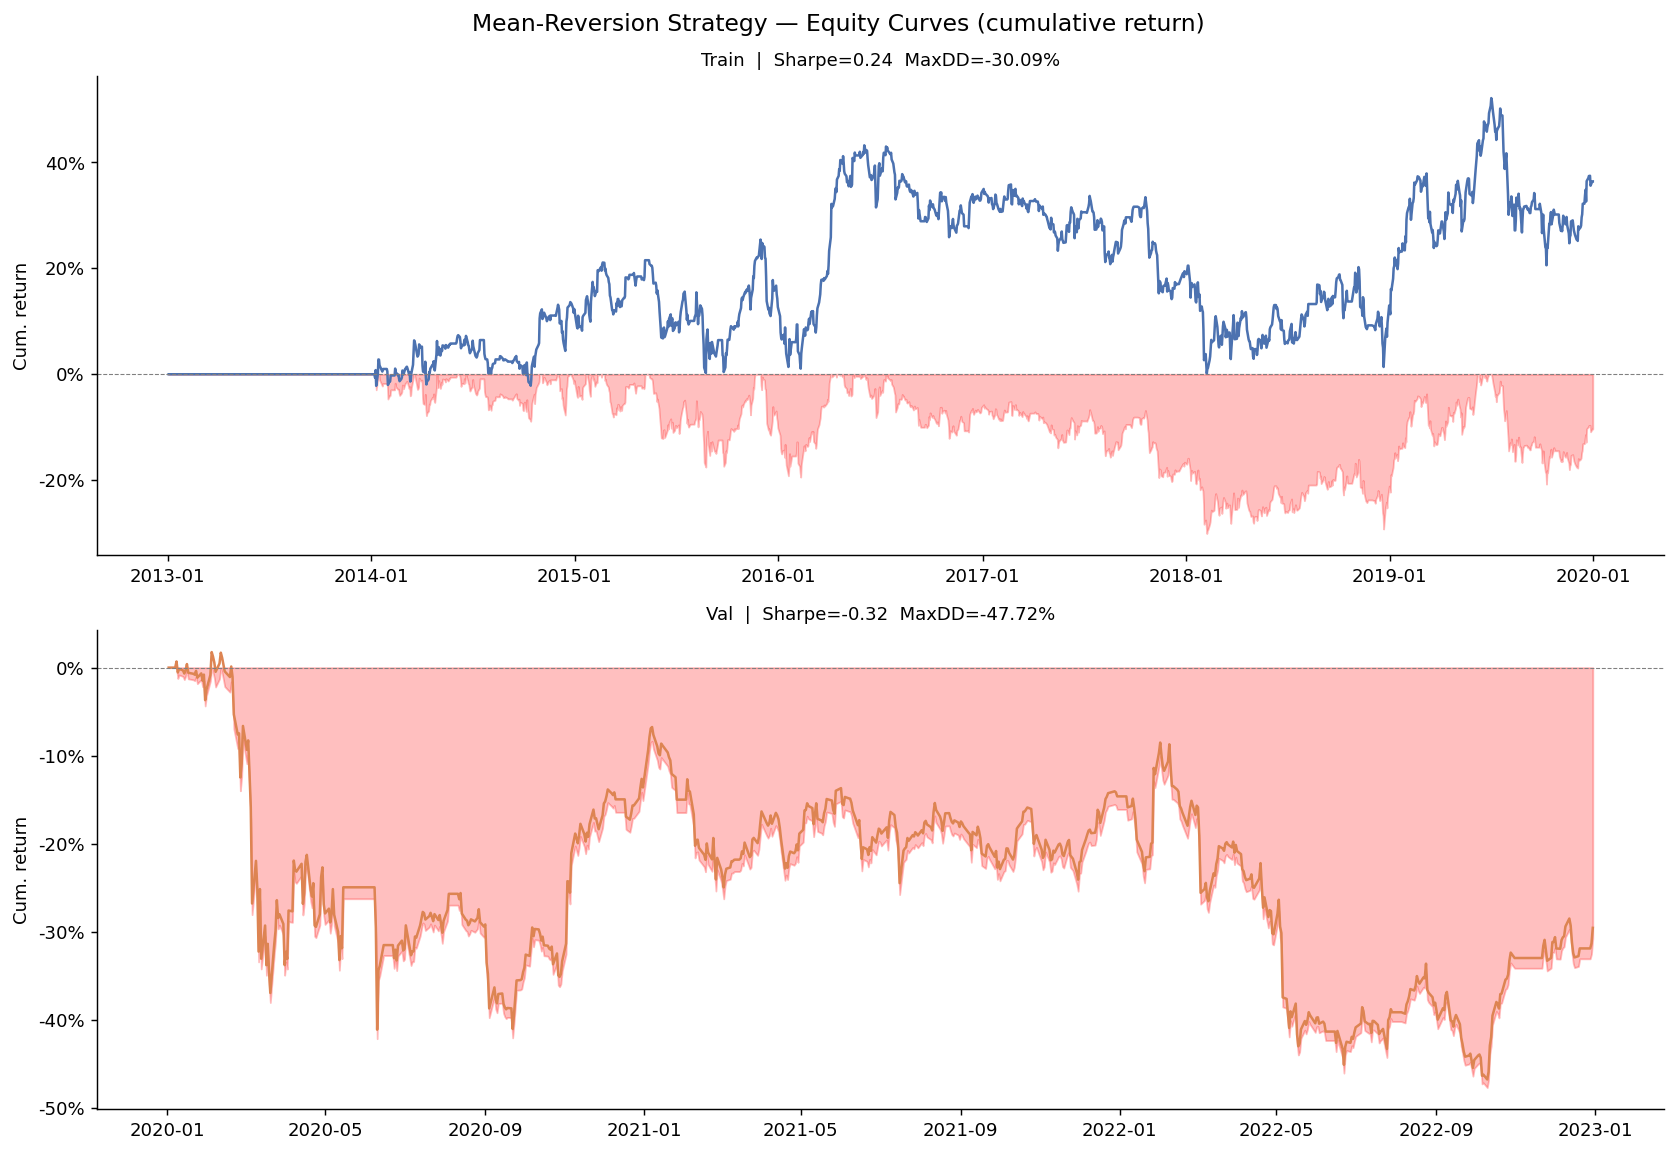

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle("Mean-Reversion Strategy — Equity Curves (cumulative return)", fontsize=13)

for ax, (name, (start, end)) in zip(axes, SPLITS.items()):
    mask = pd.Series(True, index=pnl.index)
    if start: mask &= pnl.index > start
    if end:   mask &= pnl.index <= end
    sub    = pnl[mask]
    wealth = np.exp(sub.cumsum())
    cum    = wealth - 1                    # real compounded return
    dd     = wealth / wealth.cummax() - 1  # real peak-to-trough drawdown

    color = COLORS[name]
    ax.fill_between(dd.index, dd.values, 0, alpha=0.25, color="red")
    ax.plot(cum.index, cum.values, color=color, lw=1.4, label="Cum. return")
    ax.axhline(0, color="grey", lw=0.6, ls="--")
    ax.set_title(f"{name}  |  Sharpe={sharpe(sub):.2f}  MaxDD={max_dd(sub):.2%}", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_ylabel("Cum. return")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()

## 4. Rolling Sharpe (252-day window)

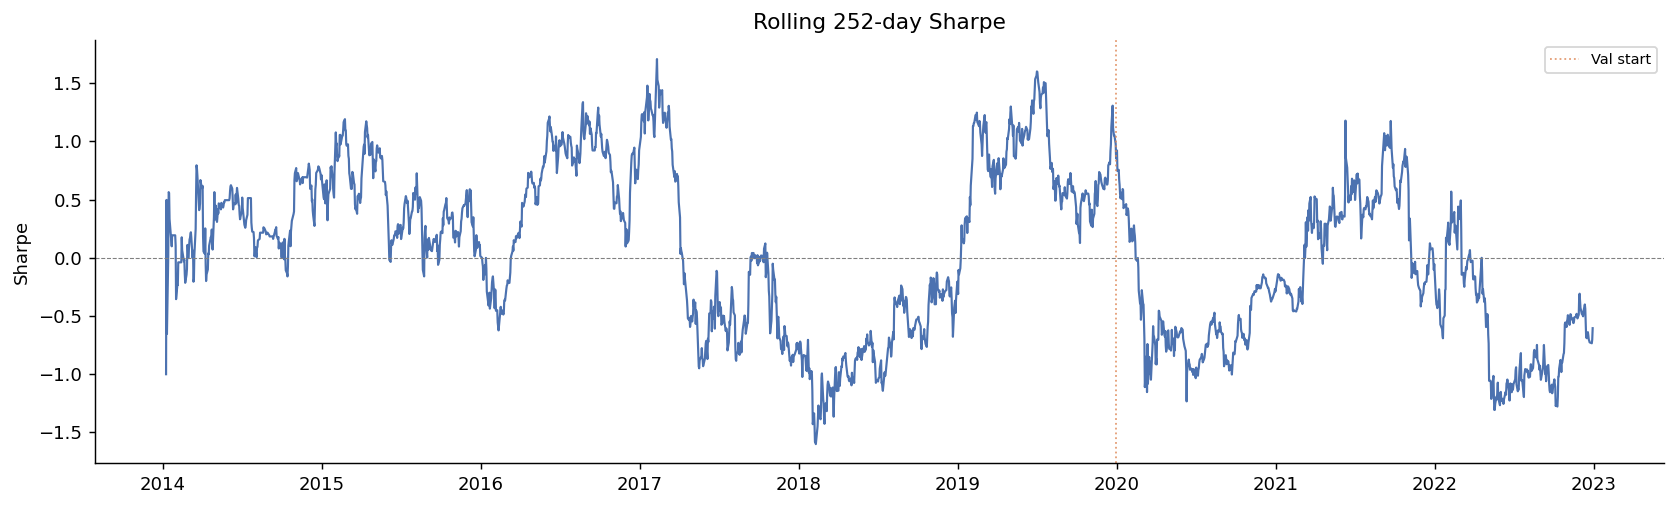

In [40]:
roll_sr = pnl.rolling(252).apply(lambda x: sharpe(pd.Series(x)), raw=False)
roll_sr = roll_sr[roll_sr.index <= VAL_END]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll_sr.index, roll_sr.values, lw=1.2, color="#4C72B0")
ax.axhline(0, color="grey", lw=0.6, ls="--")
for name, (start, end) in SPLITS.items():
    if start: ax.axvline(pd.Timestamp(start), color=COLORS[name], lw=1, ls=":", alpha=0.8, label=f"{name} start")
ax.set_title("Rolling 252-day Sharpe"); ax.set_ylabel("Sharpe"); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

## 5. Daily Return Distribution

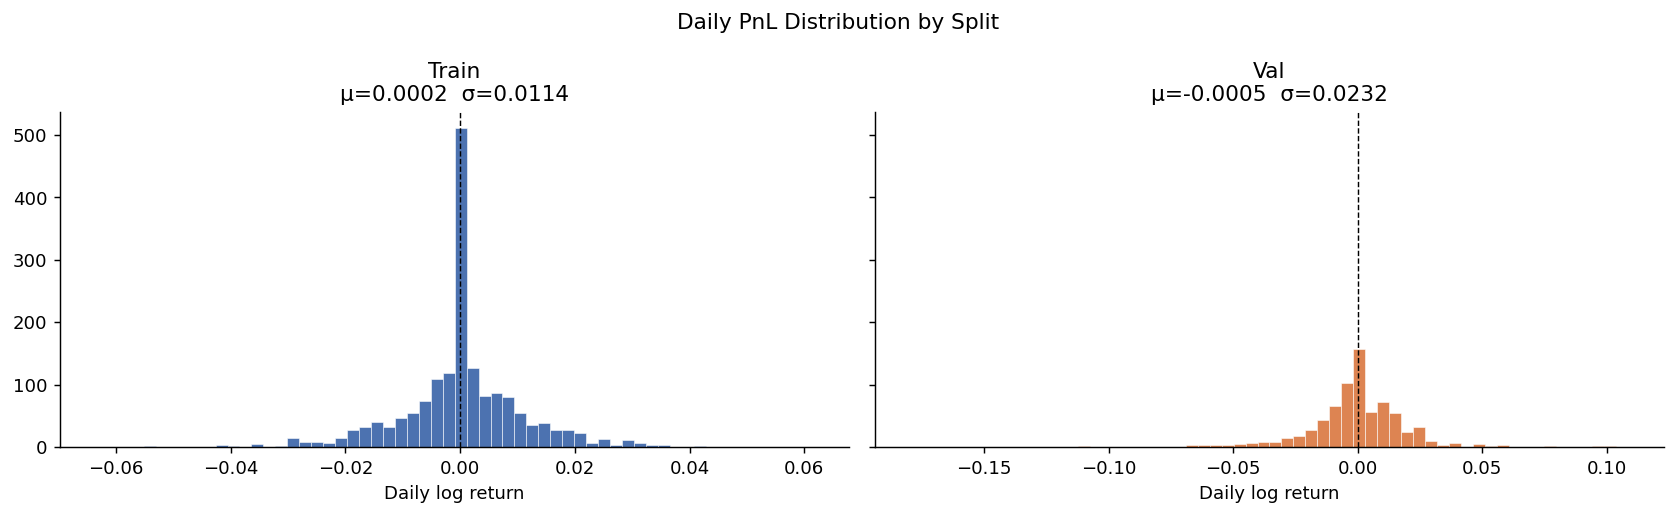

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
fig.suptitle("Daily PnL Distribution by Split", fontsize=12)

for ax, (name, (start, end)) in zip(axes, SPLITS.items()):
    mask = pd.Series(True, index=pnl.index)
    if start: mask &= pnl.index > start
    if end:   mask &= pnl.index <= end
    sub = pnl[mask]
    ax.hist(sub, bins=60, color=COLORS[name], edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_title(f"{name}\nμ={sub.mean():.4f}  σ={sub.std():.4f}")
    ax.set_xlabel("Daily log return")

plt.tight_layout(); plt.show()

# 6. Extra Statistics

In [42]:
def compute_advanced_metrics(pnl_series: pd.Series, ann_factor: int = 252) -> pd.Series:
    """
    Computes advanced risk and performance metrics for a daily PnL series.
    """
    # 1. Return & Volatility Basics
    ann_ret = np.exp(pnl_series.mean() * ann_factor) - 1
    ann_vol = pnl_series.std() * np.sqrt(ann_factor)
    
    # 2. Downside Risk (Sortino)
    downside_returns = pnl_series[pnl_series < 0]
    downside_vol = downside_returns.std() * np.sqrt(ann_factor)
    sortino = ann_ret / downside_vol if downside_vol != 0 else np.nan
    
    # 3. Drawdown & Calmar Ratio
    cum = pnl_series.cumsum()
    roll_max = cum.cummax()
    dd = cum - roll_max
    max_dd = dd.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    
    # 4. Win Rate & Profit Factor (Daily)
    win_rate = (pnl_series > 0).mean()
    gross_profit = pnl_series[pnl_series > 0].sum()
    gross_loss = abs(pnl_series[pnl_series < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.nan
    
    # 5. Tail Risk: VaR and Expected Shortfall (CVaR) at 95% confidence
    var_95 = np.percentile(pnl_series, 5)
    cvar_95 = pnl_series[pnl_series <= var_95].mean()
    
    return pd.Series({
        "Annualized Return": ann_ret,
        "Annualized Volatility": ann_vol,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_dd,
        "Calmar Ratio": calmar,
        "Daily Win Rate": win_rate,
        "Profit Factor": profit_factor,
        "Value at Risk (95%)": var_95,
        "Expected Shortfall (95%)": cvar_95
    })

print("Train Split")
print("="*50)
# Extract the PnL strictly for the Test period
train_start, train_end = SPLITS["Train"]
val_start, val_end = SPLITS["Val"]

mask = pd.Series(True, index=pnl.index)
if train_start: mask &= pnl.index > train_start
if train_end: mask &= pnl.index <= train_end
train_pnl = pnl[mask]

# Calculate and format output
metrics = compute_advanced_metrics(train_pnl)
for name, value in metrics.items():
    if "Ratio" in name or "Factor" in name:
        print(f"{name:<30}: {value:.3f}")
    elif "Rate" in name or "Return" in name or "Volatility" in name or "Risk" in name or "Shortfall" in name:
        print(f"{name:<30}: {value:.2%}")
    else:
        print(f"{name:<30}: {value:.4f}")


print("\nVal Split")
print("="*50)
mask = pd.Series(True, index=pnl.index)
if val_start: mask &= pnl.index > val_start
if val_end: mask &= pnl.index <= val_end
val_pnl = pnl[mask]

# Calculate and format output
metrics = compute_advanced_metrics(val_pnl)
for name, value in metrics.items():
    if "Ratio" in name or "Factor" in name:
        print(f"{name:<30}: {value:.3f}")
    elif "Rate" in name or "Return" in name or "Volatility" in name or "Risk" in name or "Shortfall" in name:
        print(f"{name:<30}: {value:.2%}")
    else:
        print(f"{name:<30}: {value:.4f}")

Train Split
Annualized Return             : 4.55%
Annualized Volatility         : 18.17%
Sortino Ratio                 : 0.310
Max Drawdown                  : -0.3579
Calmar Ratio                  : 0.127
Daily Win Rate                : 39.69%
Profit Factor                 : 1.049
Value at Risk (95%)           : -1.85%
Expected Shortfall (95%)      : -2.77%

Val Split
Annualized Return             : -11.03%
Annualized Volatility         : 36.78%
Sortino Ratio                 : -0.345
Max Drawdown                  : -0.6486
Calmar Ratio                  : -0.170
Daily Win Rate                : 44.05%
Profit Factor                 : 0.937
Value at Risk (95%)           : -3.58%
Expected Shortfall (95%)      : -6.04%
